In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [76]:
conn = sqlite3.connect('inventory.db')

df=pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,98952.0,3558775.48,497823.69,181812.61,68601.68,-252476.12,-7.094466,0.682051,0.933755
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,113947.0,3434886.49,414282.00,209366.61,144929.24,-369154.73,-10.747218,0.694638,0.902957
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,137527.0,3346601.73,343665.41,252694.35,123780.22,-71701.95,-2.142530,0.733841,0.979024
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,122883.0,2802775.17,308797.21,225787.27,257032.07,-458422.77,-16.356031,0.609291,0.859431
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,93554.0,2925352.46,400694.23,171894.87,257032.07,-97853.55,-3.345017,0.677392,0.967633


In [77]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,2.144162e+03,7758.973432,0.00,18.000000,156.000000,1284.250000,2.421410e+05
TotalSalesDollars,10692.0,2.925866e+04,116826.055528,0.00,371.242500,3357.820000,19444.157500,3.558775e+06
TotalSalesPrice,10692.0,1.325444e+04,32502.686900,0.00,119.955000,1749.410000,10944.835000,4.978237e+05


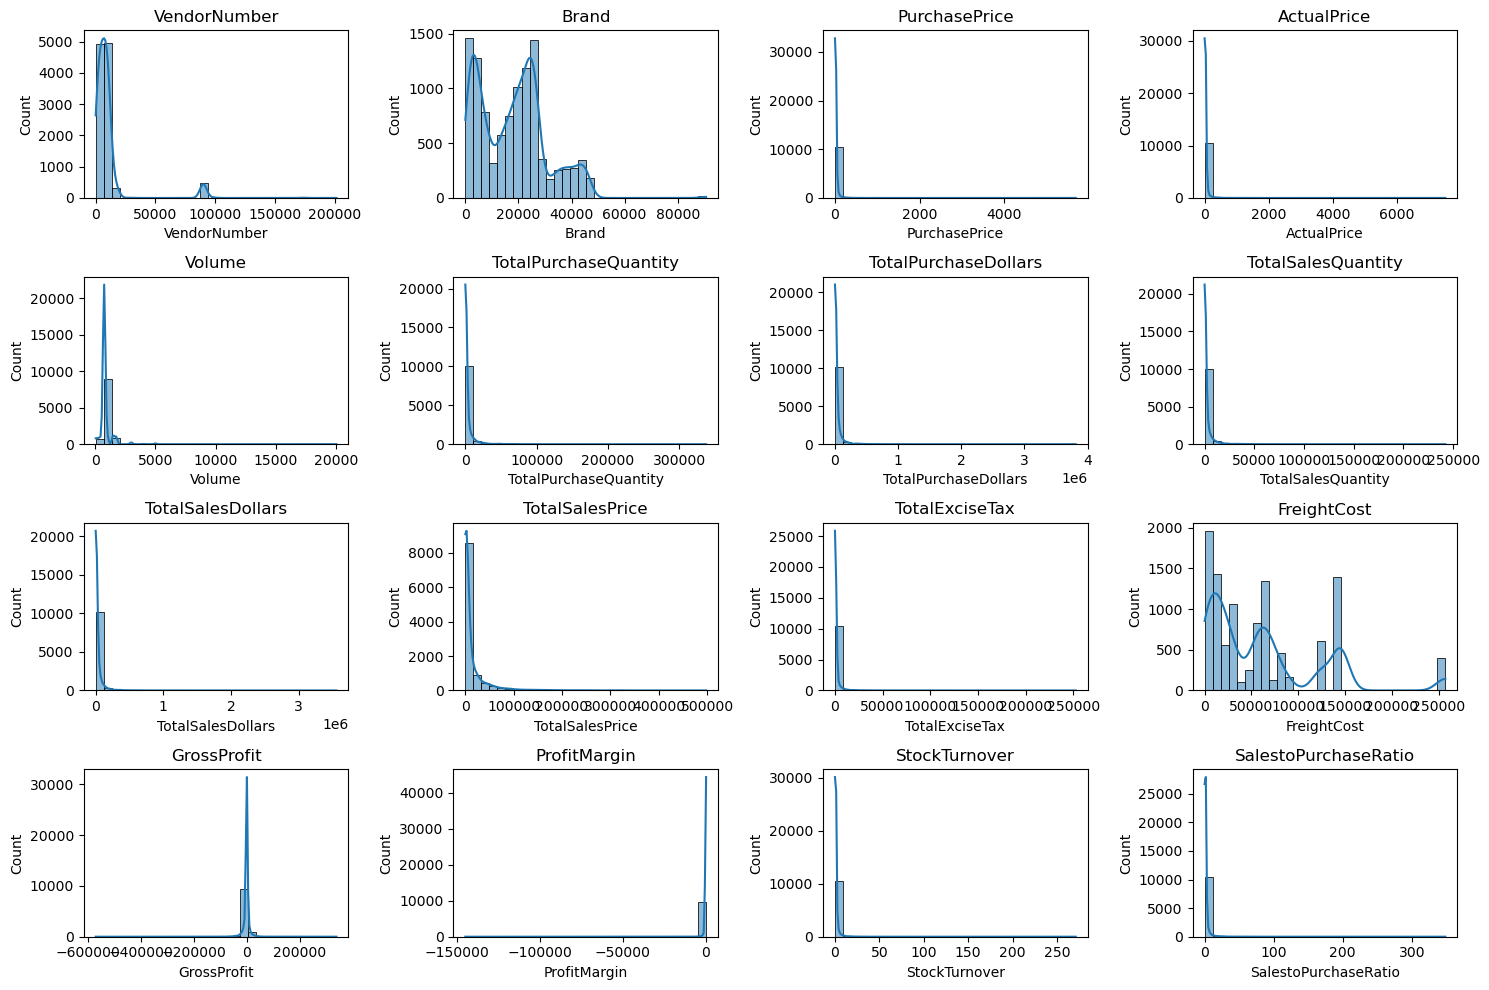

In [78]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

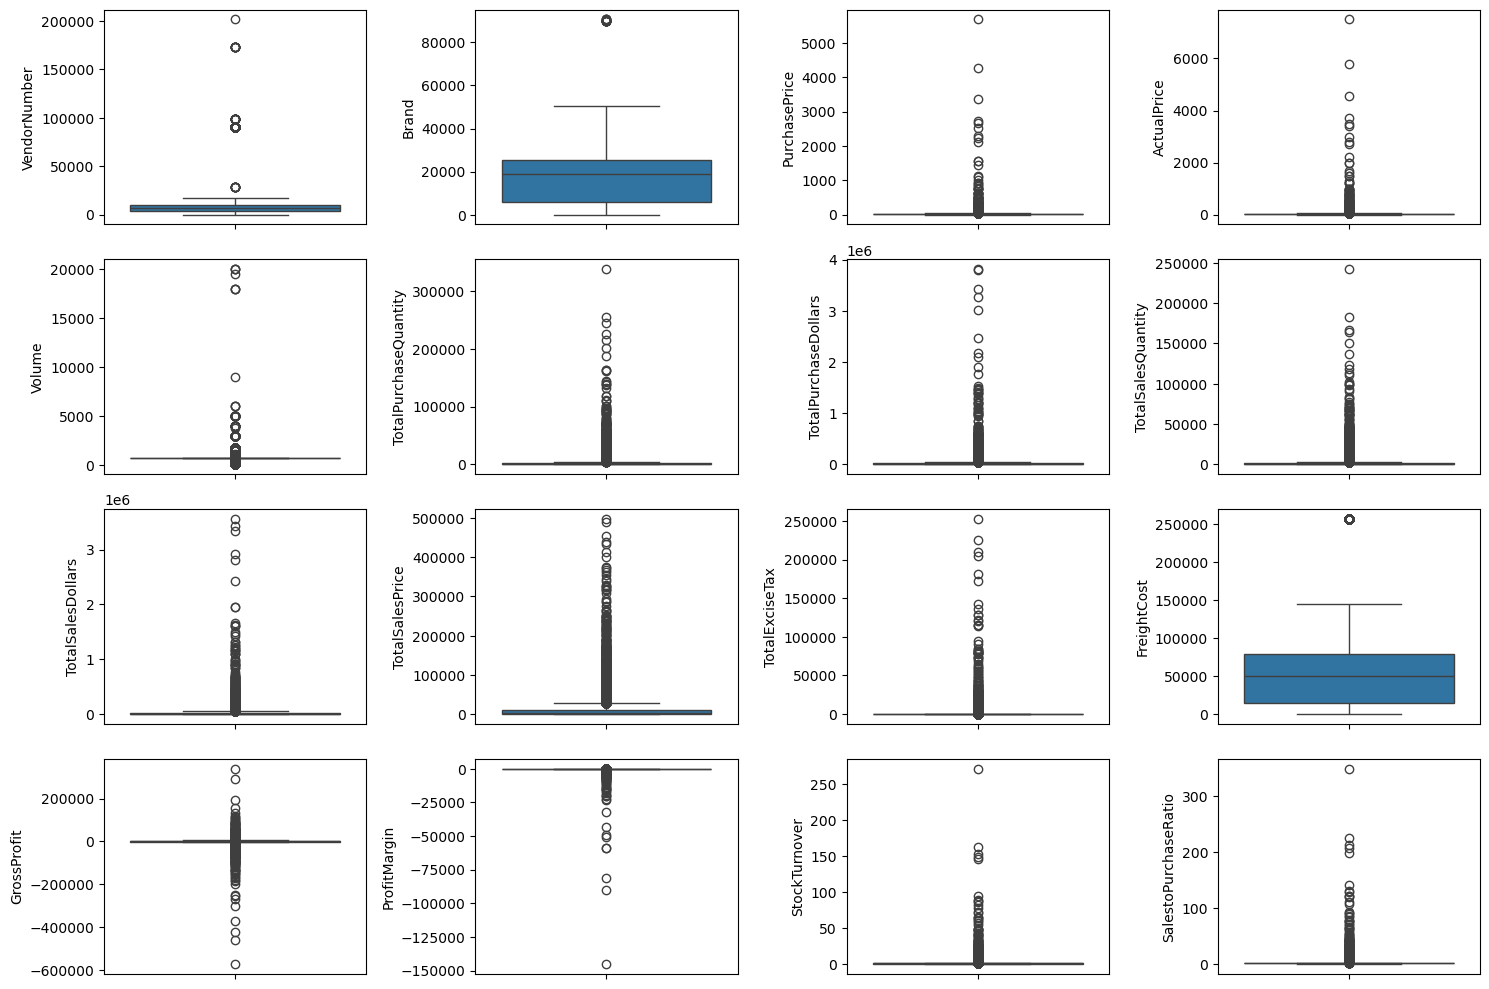

In [79]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()

In [80]:
#filtering the data by removing inconsistecies
df = pd.read_sql_query(""" SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",conn)

In [81]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,3960,DIAGEO NORTH AMERICA INC,3489,Tanqueray,20.73,27.99,1750.0,91835,1903739.55,66588.0,1960366.12,374844.09,122345.12,257032.07,56626.57,2.888571,0.725083,1.029745
1,10000,MAJESTIC FINE WINES,6570,Kendall Jackson Chard Vt RSV,6.77,10.99,750.0,215668,1460072.36,150585.0,1654904.31,140846.62,16927.80,17587.59,194831.95,11.773004,0.698226,1.133440
2,9165,ULTRA BEVERAGE COMPANY LLP,3650,Patron Silver Tequila,33.81,48.99,750.0,42951,1452173.31,31122.0,1493900.78,490840.01,24502.77,68054.70,41727.47,2.793189,0.724593,1.028734
3,3960,DIAGEO NORTH AMERICA INC,4260,Capt Morgan Original Barrel,16.66,21.99,1750.0,79078,1317439.48,77800.0,1608424.50,119159.62,142952.85,257032.07,290985.02,18.091307,0.983839,1.220872
4,480,BACARDI USA INC,3348,Bombay Sapphire Gin,22.38,29.99,1750.0,57349,1283470.62,42428.0,1321335.72,340494.60,77956.64,89286.27,37865.10,2.865668,0.739821,1.029502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5498,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,12.0,23.88,1.99,0.63,257032.07,21.04,88.107203,6.000000,8.408451
5499,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
5500,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
5501,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,57.0,113.43,55.72,11.97,257032.07,111.96,98.704047,57.000000,77.163265


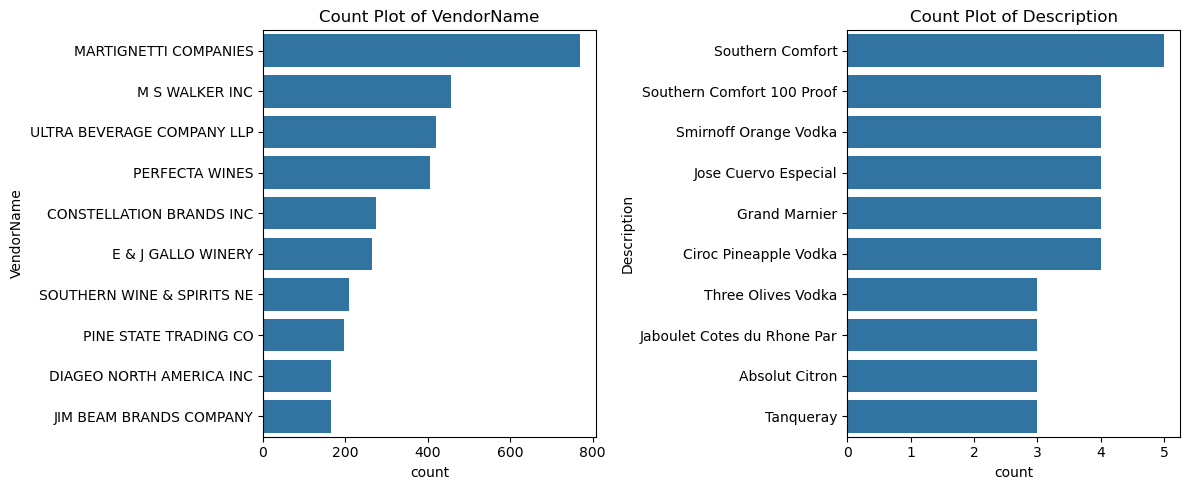

In [82]:
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) #Top 10 catogories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

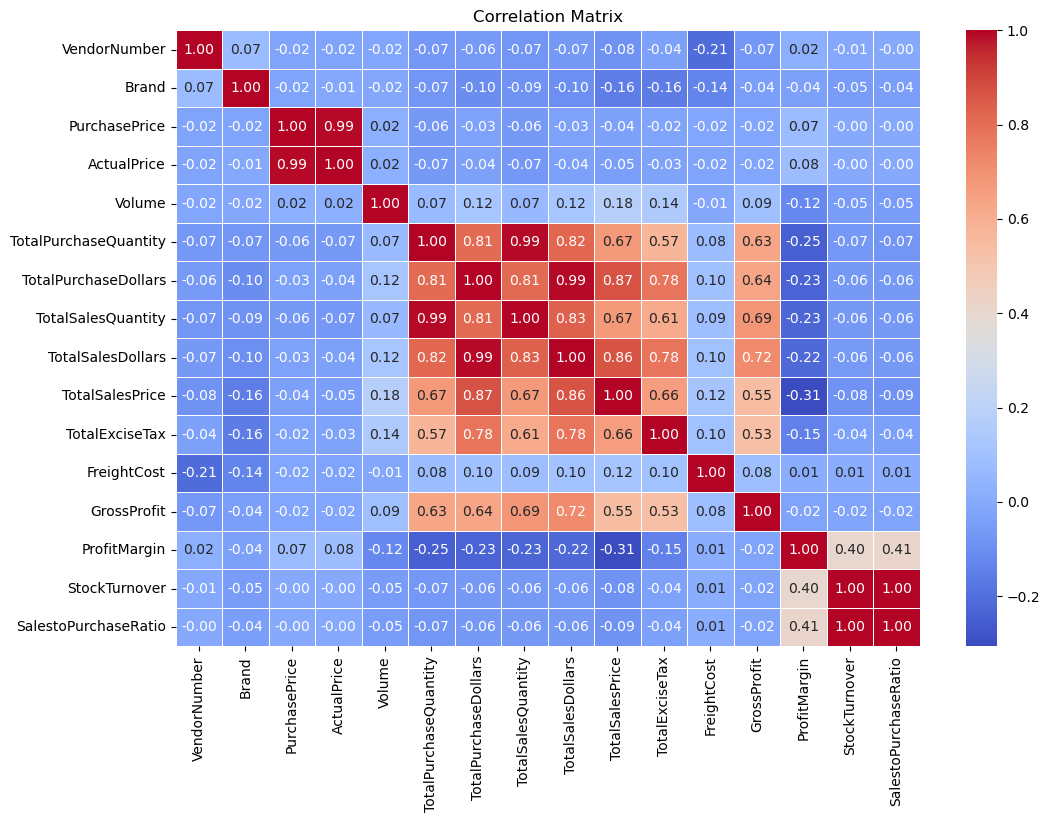

In [83]:
plt.figure(figsize=(12, 8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [84]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [85]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [86]:
low_sales_threshold

np.float64(503.64)

In [87]:
high_margin_threshold

np.float64(73.73487161523148)

In [88]:
#filtering brands with low sales but higher profit margin
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margin: ")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margin: 


,Description,TotalSalesDollars,ProfitMargin
1519,Concannon Glen Ellen Wh Zin,15.95,83.448276
1598,Crown Royal Apple,23.88,88.107203
4187,Sauza Sprklg Wild Berry Marg,27.96,82.153076
4835,Tracia Syrah,44.94,88.495772
405,Basilica Amaretto,47.45,85.079031
...,...,...,...
5085,Wolf Blass Yellow Lbl Chard,494.45,83.351198
3471,Ninety+Cellars Lot 71 Malbec,494.67,87.955607
3403,Nanbu Bijin Southern Beauty,495.70,74.871898
2575,Jack Daniels 2 Yr Rested Rye,499.90,92.424485


In [89]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] #better visualization

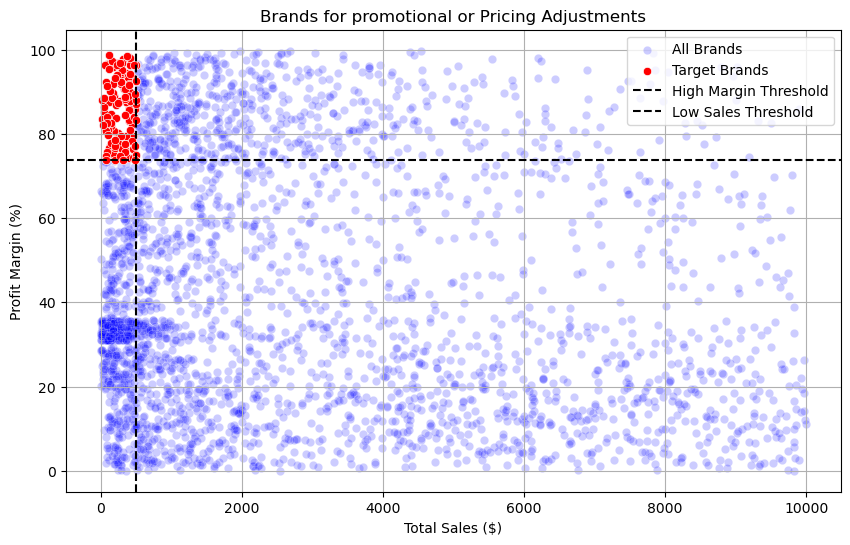

In [90]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

In [91]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [92]:
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
MARTIGNETTI COMPANIES         16756501.09
CONSTELLATION BRANDS INC      13687921.44
DIAGEO NORTH AMERICA INC      13118246.97
E & J GALLO WINERY             9357768.84
ULTRA BEVERAGE COMPANY LLP     7574626.82
BACARDI USA INC                7417966.75
PROXIMO SPIRITS INC.           7044090.24
M S WALKER INC                 6779423.51
JIM BEAM BRANDS COMPANY        6179787.45
WINE GROUP INC                 5715387.74
Name: TotalSalesDollars, dtype: float64

In [93]:
top_brands.apply(lambda x : format_dollars(x))

Description
Tanqueray                         2.44M
Bombay Sapphire Gin               1.90M
Jose Cuervo Especial              1.87M
Kendall Jackson Chard Vt RSV      1.65M
Capt Morgan Original Barrel       1.61M
Patron Silver Tequila             1.54M
Bacardi Superior Rum Trav         1.52M
Three Olives Vodka                1.28M
Smirnoff 80 Proof                 1.08M
Grand Marnier                   961.90K
Name: TotalSalesDollars, dtype: object

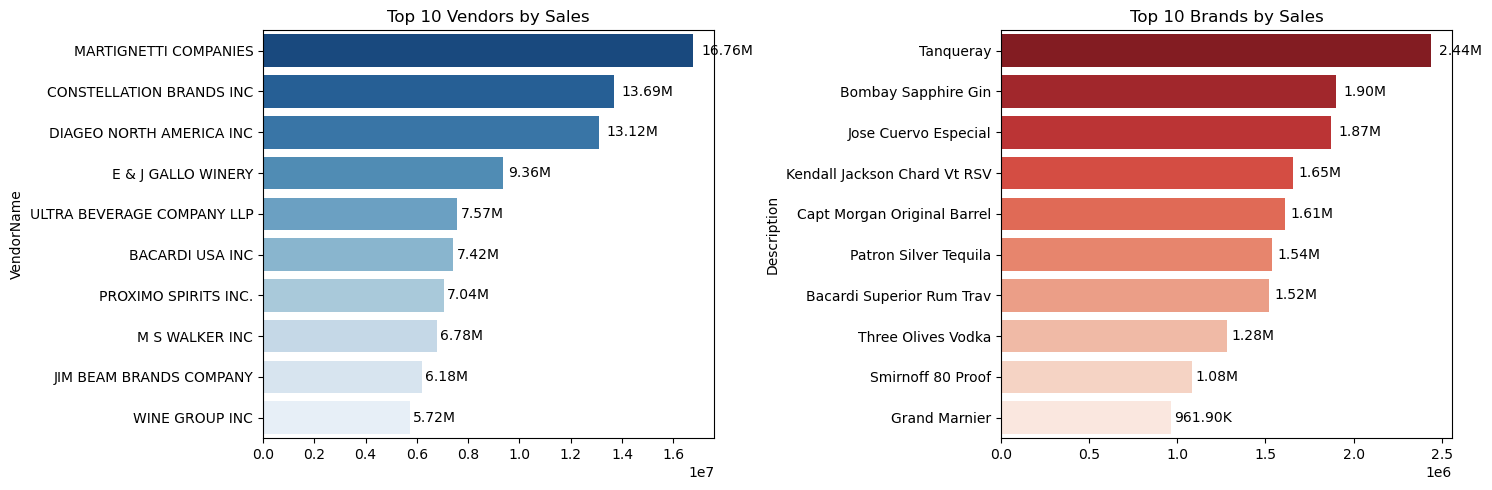

In [94]:
plt.figure(figsize=(15, 5))

#plot for top vendors
plt.subplot(1, 2, 1)
ax1=sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

#plot for top brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [95]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

(102, 4)

In [96]:
vendor_performance['PurchaseConribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()*100

In [97]:
vendor_performance = round(vendor_performance.sort_values('PurchaseConribution%', ascending= False),2)

In [98]:
#Displaying top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseConribution%
48,MARTIGNETTI COMPANIES,13.24M,3.52M,16.76M,10.37
21,DIAGEO NORTH AMERICA INC,11.83M,1.29M,13.12M,9.26
16,CONSTELLATION BRANDS INC,11.48M,2.21M,13.69M,8.99
25,E & J GALLO WINERY,8.11M,1.25M,9.36M,6.35
64,PROXIMO SPIRITS INC.,6.35M,692.73K,7.04M,4.97
3,BACARDI USA INC,6.32M,1.09M,7.42M,4.95
91,ULTRA BEVERAGE COMPANY LLP,6.05M,1.53M,7.57M,4.74
45,M S WALKER INC,5.60M,1.18M,6.78M,4.39
38,JIM BEAM BRANDS COMPANY,5.45M,733.39K,6.18M,4.27
100,WINE GROUP INC,4.86M,855.43K,5.72M,3.81


In [99]:
top_vendors['PurchaseConribution%'].sum()

np.float64(62.099999999999994)

In [100]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseConribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseConribution%,Cumulative_Contribution%
48,MARTIGNETTI COMPANIES,13.24M,3.52M,16.76M,10.37,10.37
21,DIAGEO NORTH AMERICA INC,11.83M,1.29M,13.12M,9.26,19.63
16,CONSTELLATION BRANDS INC,11.48M,2.21M,13.69M,8.99,28.62
25,E & J GALLO WINERY,8.11M,1.25M,9.36M,6.35,34.97
64,PROXIMO SPIRITS INC.,6.35M,692.73K,7.04M,4.97,39.94
3,BACARDI USA INC,6.32M,1.09M,7.42M,4.95,44.89
91,ULTRA BEVERAGE COMPANY LLP,6.05M,1.53M,7.57M,4.74,49.63
45,M S WALKER INC,5.60M,1.18M,6.78M,4.39,54.02
38,JIM BEAM BRANDS COMPANY,5.45M,733.39K,6.18M,4.27,58.29
100,WINE GROUP INC,4.86M,855.43K,5.72M,3.81,62.10


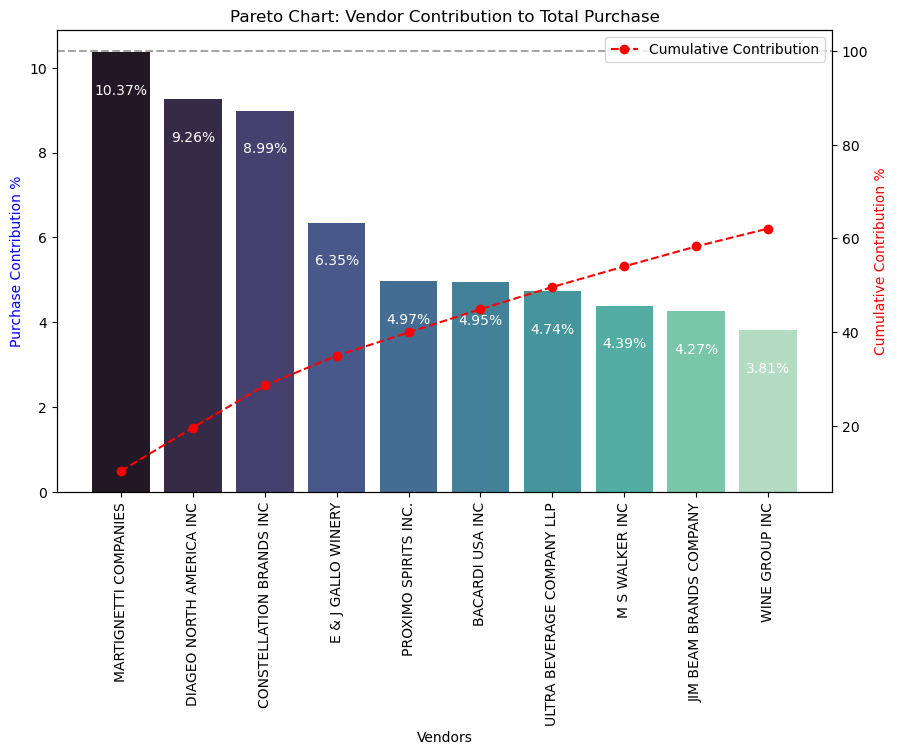

In [101]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseConribution%'].cumsum()
fig, ax1 = plt.subplots(figsize=(10, 6))

#Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseConribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseConribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

#line plot for cumulative contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label = 'Cumulative Contribution')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchase')

ax2.axhline(y=100, color='gray',linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

In [102]:
print(f"Total Purchase Contribution of top 10 Vendors is {round(top_vendors['PurchaseConribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 Vendors is 62.1 %


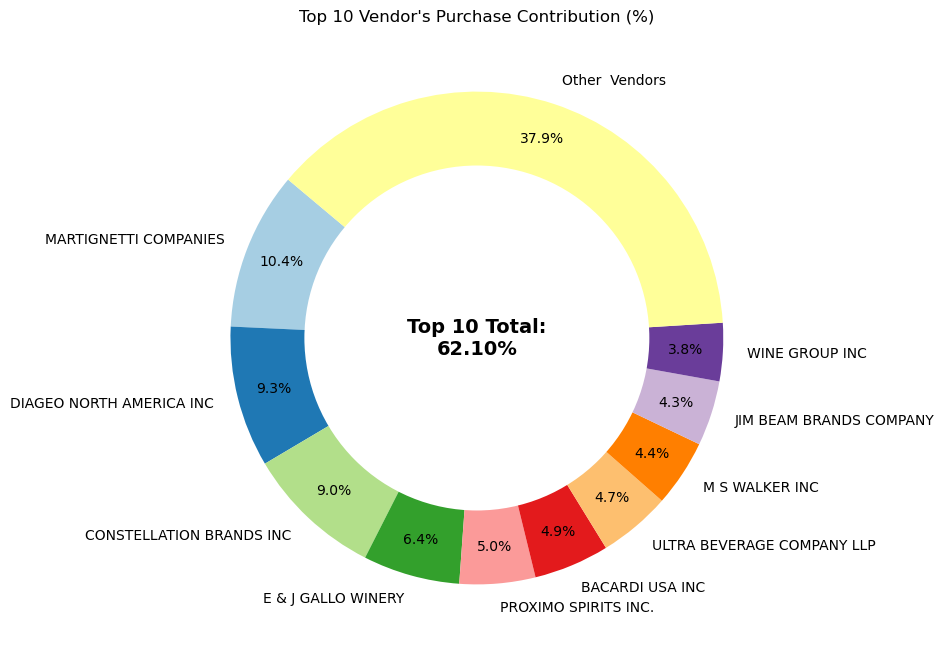

In [103]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseConribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

#append "other vendors" category
vendors.append("Other  Vendors")
purchase_contributions.append(remaining_contribution)

#Donut chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                 startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

#Drawing a white circle in the middle to get the "donut" effect
center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(center_circle)

#Add total contribution anotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

In [104]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [105]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice
0,3960,DIAGEO NORTH AMERICA INC,3489,Tanqueray,20.73,27.99,1750.0,91835,1903739.55,66588.0,1960366.12,374844.09,122345.12,257032.07,56626.57,2.888571,0.725083,1.029745,20.73
1,10000,MAJESTIC FINE WINES,6570,Kendall Jackson Chard Vt RSV,6.77,10.99,750.0,215668,1460072.36,150585.0,1654904.31,140846.62,16927.80,17587.59,194831.95,11.773004,0.698226,1.133440,6.77
2,9165,ULTRA BEVERAGE COMPANY LLP,3650,Patron Silver Tequila,33.81,48.99,750.0,42951,1452173.31,31122.0,1493900.78,490840.01,24502.77,68054.70,41727.47,2.793189,0.724593,1.028734,33.81
3,3960,DIAGEO NORTH AMERICA INC,4260,Capt Morgan Original Barrel,16.66,21.99,1750.0,79078,1317439.48,77800.0,1608424.50,119159.62,142952.85,257032.07,290985.02,18.091307,0.983839,1.220872,16.66
4,480,BACARDI USA INC,3348,Bombay Sapphire Gin,22.38,29.99,1750.0,57349,1283470.62,42428.0,1321335.72,340494.60,77956.64,89286.27,37865.10,2.865668,0.739821,1.029502,22.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5498,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,12.0,23.88,1.99,0.63,257032.07,21.04,88.107203,6.000000,8.408451,1.42
5499,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
5500,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
5501,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,57.0,113.43,55.72,11.97,257032.07,111.96,98.704047,57.000000,77.163265,1.47


In [106]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [107]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,91835
1,Large,215668
2,Large,42951
3,Large,79078
4,Large,57349
...,...,...
5498,Small,2
5499,Small,2
5500,Small,6
5501,Small,1


In [108]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,46.016025
Medium,13.496527
Large,8.711657


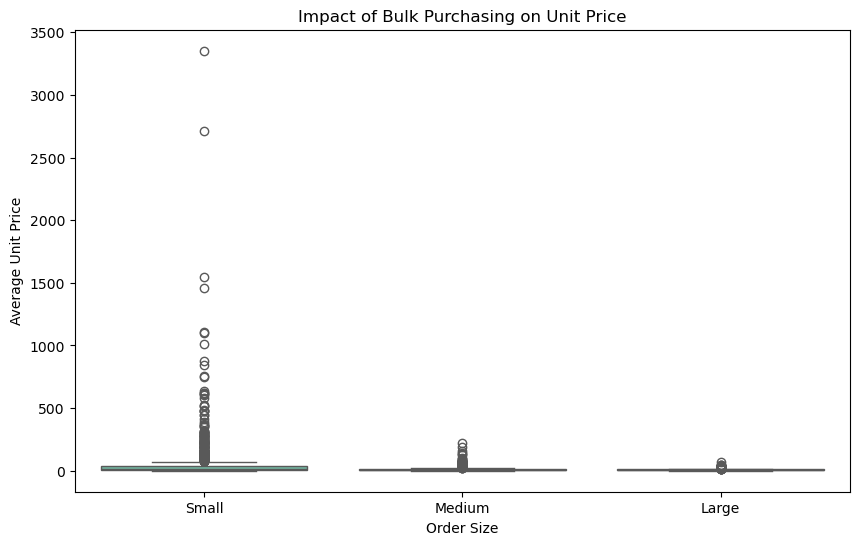

In [109]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Price")
plt.show()

In [110]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending = True)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.500000
THE IMPORTED GRAPE LLC,0.661937
WEIN BAUER INC,0.666667
Dunn Wine Brokers,0.666667
TY KU LLC,0.667911
...,...
VRANKEN AMERICA,0.858977
FABRIZIA SPIRITS LLC,0.865931
MILTONS DISTRIBUTING CO,0.916667


In [111]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 28.65M


In [112]:
#Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

#Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
16,CONSTELLATION BRANDS INC,3.15M
48,MARTIGNETTI COMPANIES,2.86M
21,DIAGEO NORTH AMERICA INC,2.38M
25,E & J GALLO WINERY,2.28M
100,WINE GROUP INC,1.38M
64,PROXIMO SPIRITS INC.,1.37M
45,M S WALKER INC,1.32M
38,JIM BEAM BRANDS COMPANY,1.04M
3,BACARDI USA INC,1.02M
91,ULTRA BEVERAGE COMPANY LLP,976.31K


In [113]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [114]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [115]:
top_vendors

0        2.888571
1       11.773004
2        2.793189
3       18.091307
4        2.865668
          ...    
2822    89.626680
2823    89.883453
2859    88.617209
2892    94.782869
2976    93.827681
Name: ProfitMargin, Length: 1376, dtype: float64

In [116]:
low_vendors

3457     1.108003
3476     2.768751
3492     5.421184
3499     2.962678
3514     8.403737
          ...    
5498    88.107203
5499    83.448276
5500    96.436186
5501    98.704047
5502    99.166079
Name: ProfitMargin, Length: 1376, dtype: float64

In [119]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) -1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (15.28, 16.84), Mean: 16.06
Low Vendors 95% CI: (43.71, 46.56), Mean: 45.14


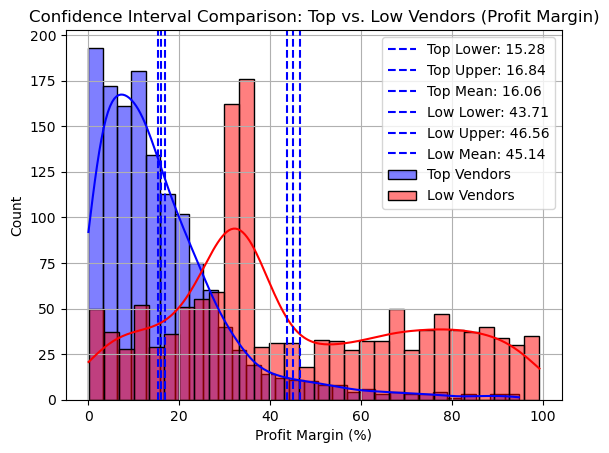

In [121]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

#Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="--", label=f"Top Mean: {top_mean:.2f}")

#Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="blue", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="blue", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="blue", linestyle="--", label=f"Low Mean: {low_mean:.2f}")

#Finalizng Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.legend()
plt.grid(True)
plt.show()

In [123]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

#performing Two-Sample  T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

#Print result
print(f"T-Statistics: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: There is a significant difference in profit margin between top and low-performing Vendors.")
else:
    print("Fail to Reject H0: No significant difference in profit margin.")

T-Statistics: -35.1392, P-Value: 0.0000
Reject H0: There is a significant difference in profit margin between top and low-performing Vendors.
